In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("./structured_smart_city_dataset.csv")

## 1. Understanding the dataset

In [3]:
df.shape

(7000, 13)

In [4]:
df.columns

Index(['Age', 'Household_Size', 'Monthly_Electricity_Usage_kWh',
       'Monthly_Water_Usage_Liters', 'Monthly_Gas_Usage_Units',
       'Work_From_Home_Days_Per_Month', 'Vehicle_Owned',
       'Public_Transport_Usage_Per_Month', 'Monthly_Internet_Usage_GB',
       'Smart_Device_Count', 'Monthly_Grocery_Spending', 'Recycling_Score',
       'Carbon_Footprint_Index'],
      dtype='str')

In [7]:
df.head()

,Age,Household_Size,Monthly_Electricity_Usage_kWh,Monthly_Water_Usage_Liters,Monthly_Gas_Usage_Units,Work_From_Home_Days_Per_Month,Vehicle_Owned,Public_Transport_Usage_Per_Month,Monthly_Internet_Usage_GB,Smart_Device_Count,Monthly_Grocery_Spending,Recycling_Score,Carbon_Footprint_Index
0,55,7,577.815435,16297.185213,250.452177,0,2,5,136.910641,5,22434.354466,39.515578,316.954231
1,44,2,262.106859,8997.944363,178.673805,5,1,35,217.895776,8,15304.246020,85.444985,162.026964
2,26,4,321.466128,8171.473190,81.168415,9,1,26,179.480453,5,13206.258639,91.175188,172.257279
3,46,3,726.628283,12595.167596,352.260102,7,2,0,249.277214,7,17872.913293,25.030369,394.199926
4,36,2,432.306960,5435.629369,204.876572,18,1,29,375.182923,13,9987.818482,44.094452,274.378229


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

Age                                 0
Household_Size                      0
Monthly_Electricity_Usage_kWh       0
Monthly_Water_Usage_Liters          0
Monthly_Gas_Usage_Units             0
Work_From_Home_Days_Per_Month       0
Vehicle_Owned                       0
Public_Transport_Usage_Per_Month    0
Monthly_Internet_Usage_GB           0
Smart_Device_Count                  0
Monthly_Grocery_Spending            0
Recycling_Score                     0
Carbon_Footprint_Index              0
dtype: int64

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               7000 non-null   int64  
 1   Household_Size                    7000 non-null   int64  
 2   Monthly_Electricity_Usage_kWh     7000 non-null   float64
 3   Monthly_Water_Usage_Liters        7000 non-null   float64
 4   Monthly_Gas_Usage_Units           7000 non-null   float64
 5   Work_From_Home_Days_Per_Month     7000 non-null   int64  
 6   Vehicle_Owned                     7000 non-null   int64  
 7   Public_Transport_Usage_Per_Month  7000 non-null   int64  
 8   Monthly_Internet_Usage_GB         7000 non-null   float64
 9   Smart_Device_Count                7000 non-null   int64  
 10  Monthly_Grocery_Spending          7000 non-null   float64
 11  Recycling_Score                   7000 non-null   float64
 12  Carbon_Footprint_

In [9]:
df.describe()

,Age,Household_Size,Monthly_Electricity_Usage_kWh,Monthly_Water_Usage_Liters,Monthly_Gas_Usage_Units,Work_From_Home_Days_Per_Month,Vehicle_Owned,Public_Transport_Usage_Per_Month,Monthly_Internet_Usage_GB,Smart_Device_Count,Monthly_Grocery_Spending,Recycling_Score,Carbon_Footprint_Index
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,41.023571,3.619000,525.077941,11969.774015,275.452334,8.800286,1.264429,17.026000,250.289803,7.917429,18032.520179,53.725632,302.776230
std,10.647525,1.790135,177.028776,4917.857886,107.733052,6.360045,0.963807,13.106863,100.358655,4.059042,5801.338479,22.590858,94.735071
min,22.000000,1.000000,184.023592,3163.716659,81.168415,0.000000,0.000000,0.000000,58.813493,2.000000,4534.631240,-6.352002,121.671156
25%,33.000000,2.000000,361.413993,7553.656306,172.588255,3.000000,1.000000,4.750000,174.379131,5.000000,13284.851642,35.572436,215.131575
50%,40.000000,4.000000,515.369999,10323.590316,257.807704,7.000000,1.000000,15.000000,221.069022,7.000000,17224.120690,49.168872,301.512958
75%,50.000000,5.000000,689.399332,16349.788187,373.701985,14.250000,2.000000,25.000000,326.301851,11.000000,22192.722235,76.450040,385.242142
max,64.000000,7.000000,924.793889,27201.955433,511.959181,21.000000,3.000000,49.000000,539.009575,17.000000,37141.973645,102.048670,554.372528


## 2. Outlier Analysis

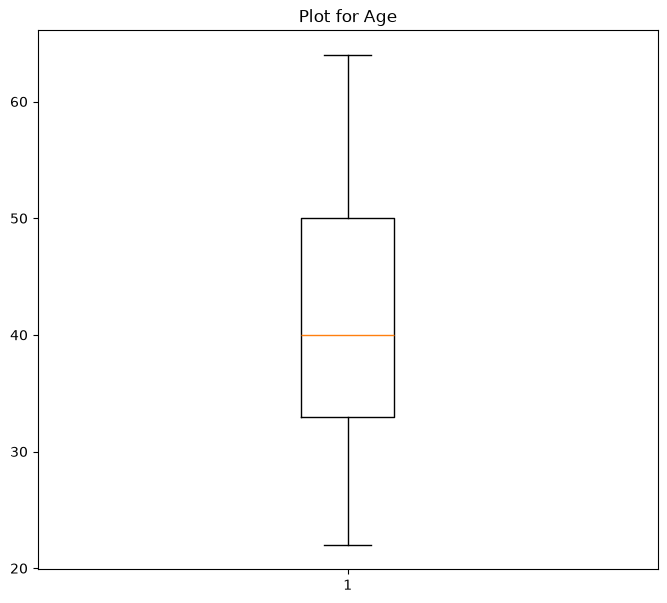

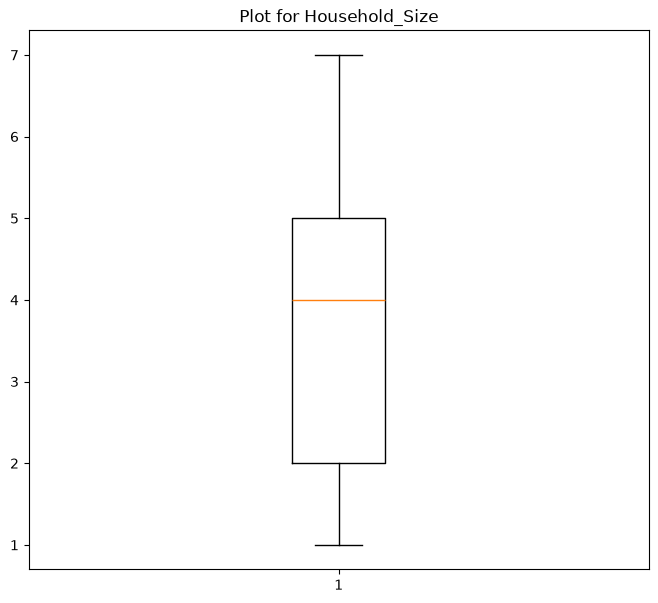

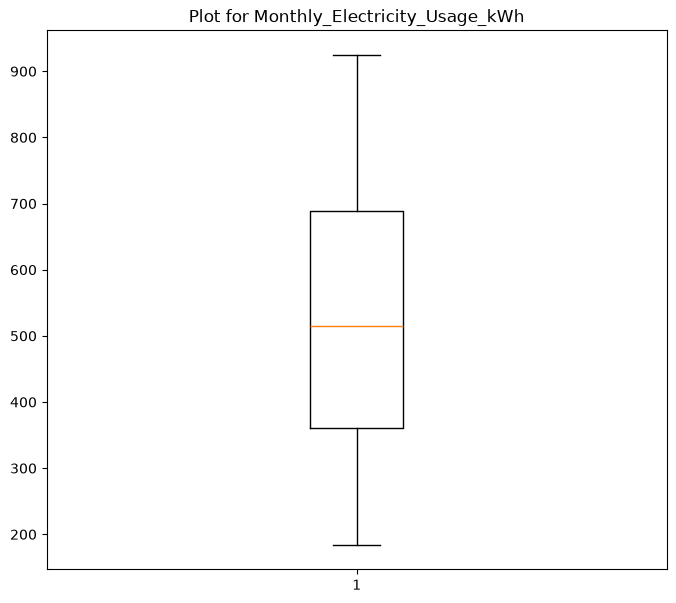

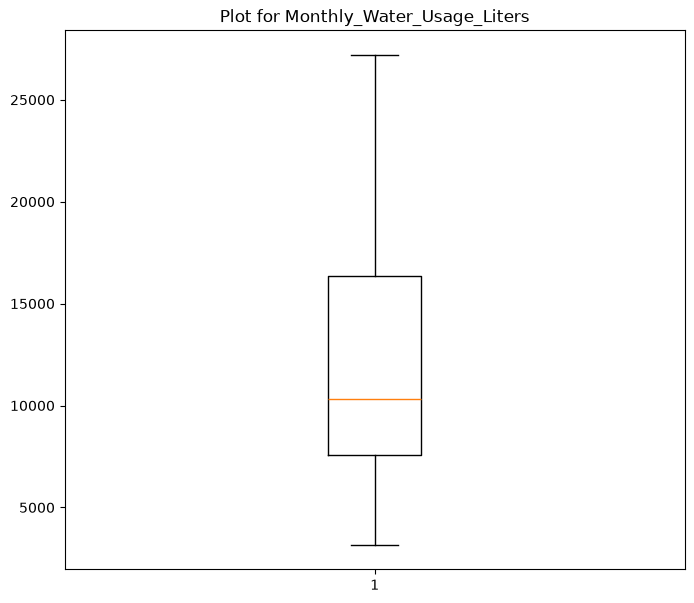

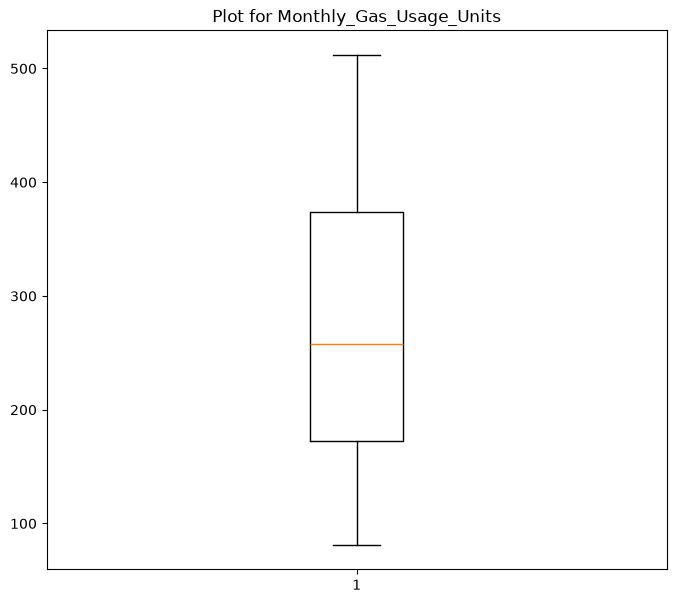

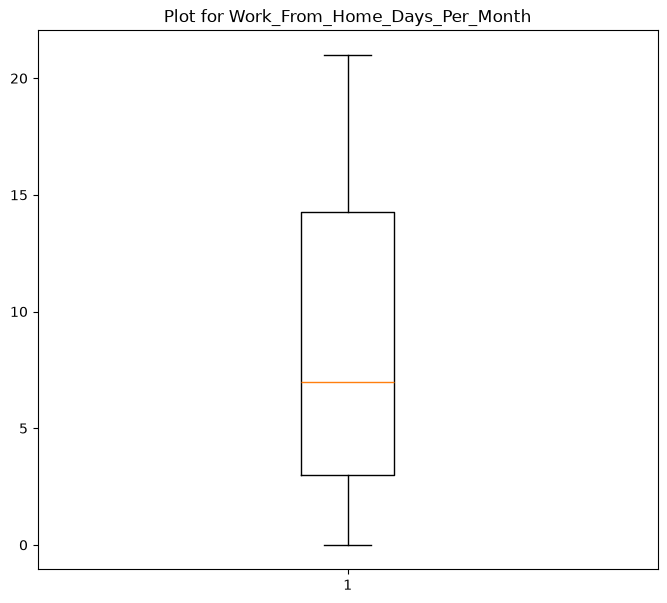

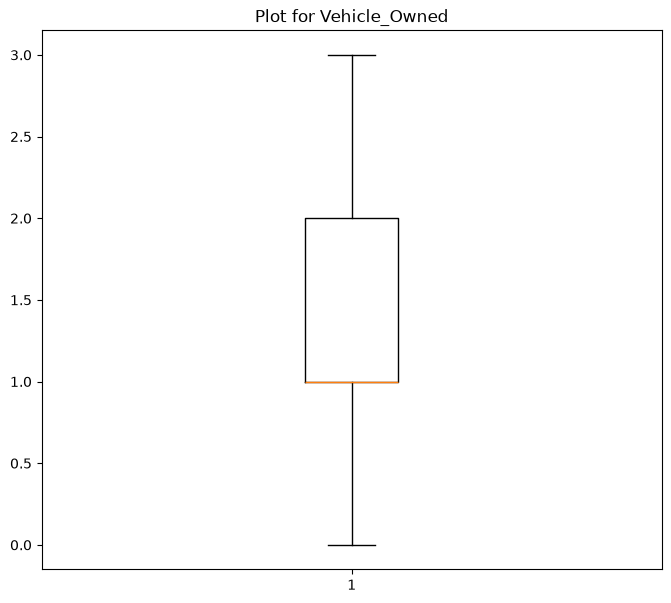

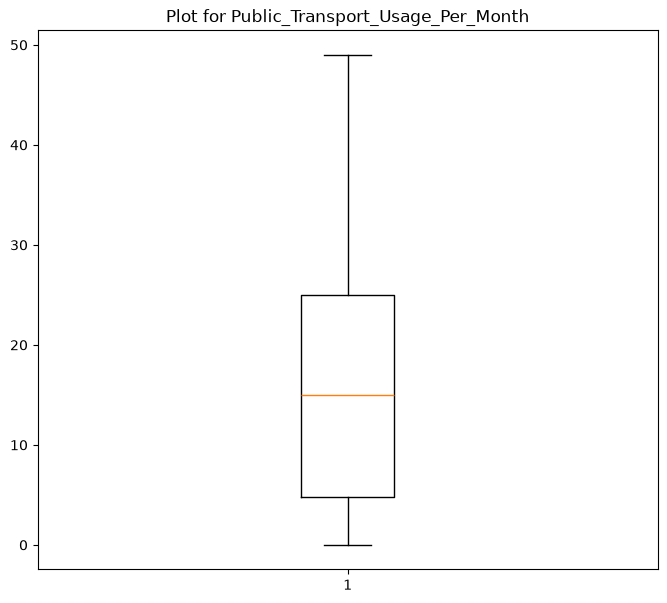

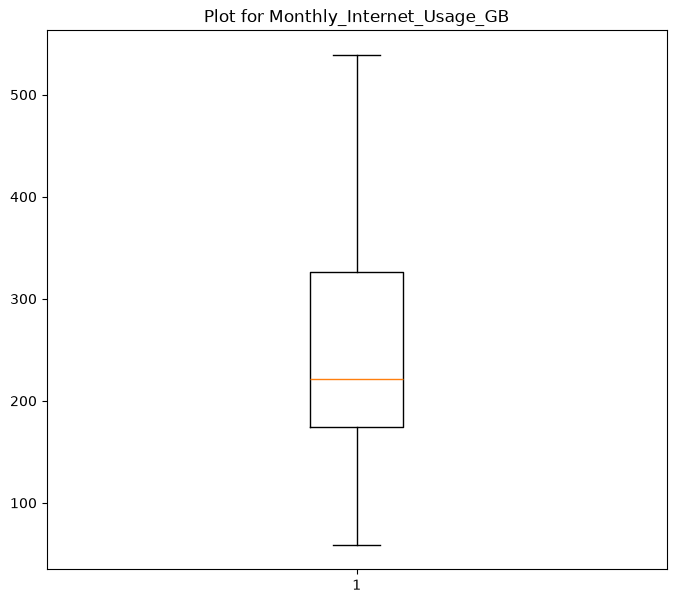

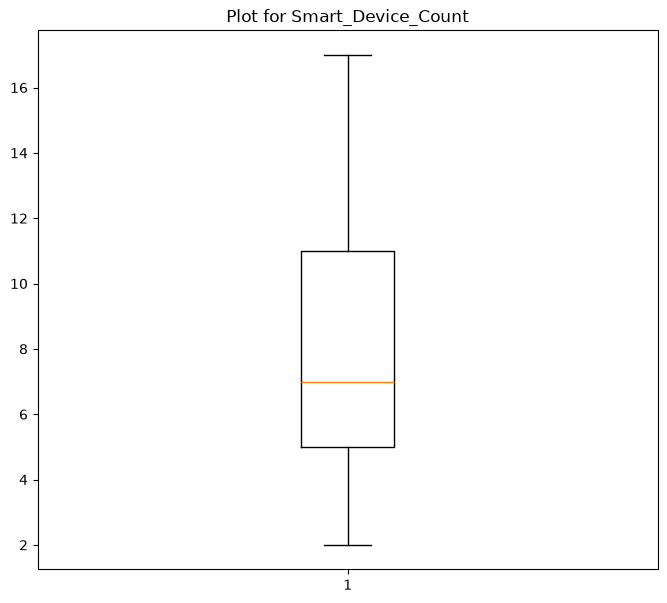

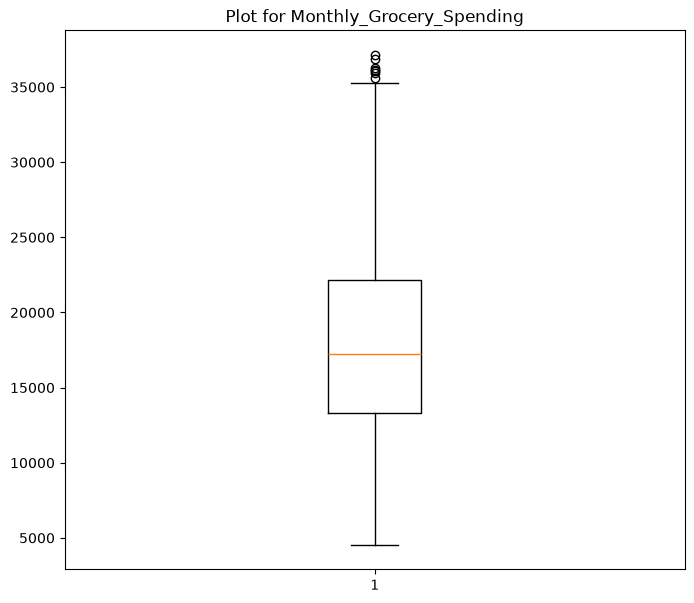

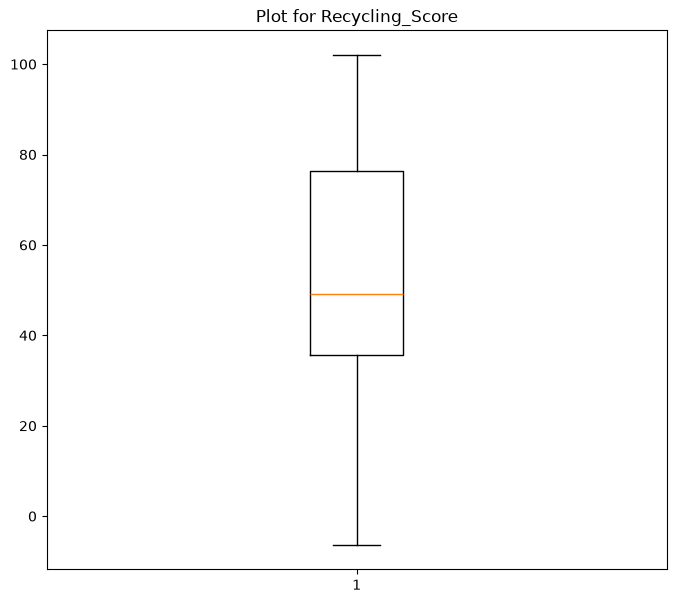

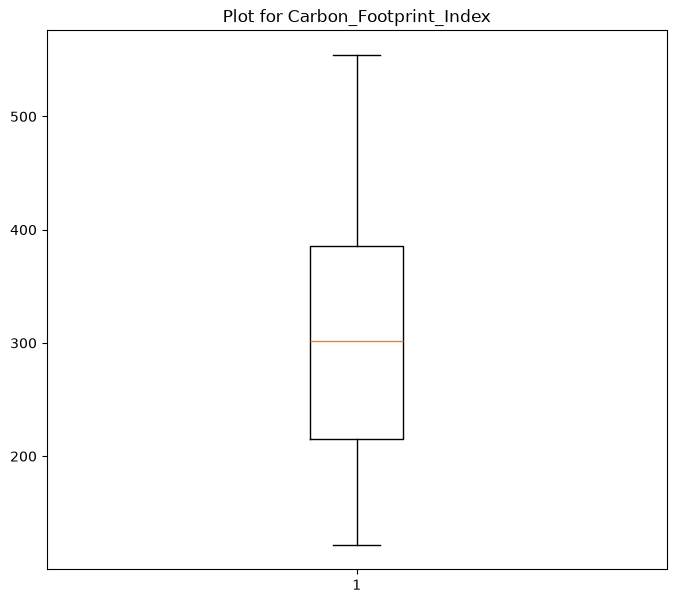

In [10]:
for col in df.select_dtypes(include='number'):
    plt.figure(figsize=(8,7))
    plt.boxplot(x=df[col])
    plt.title(f"Plot for {col}")
    plt.show()

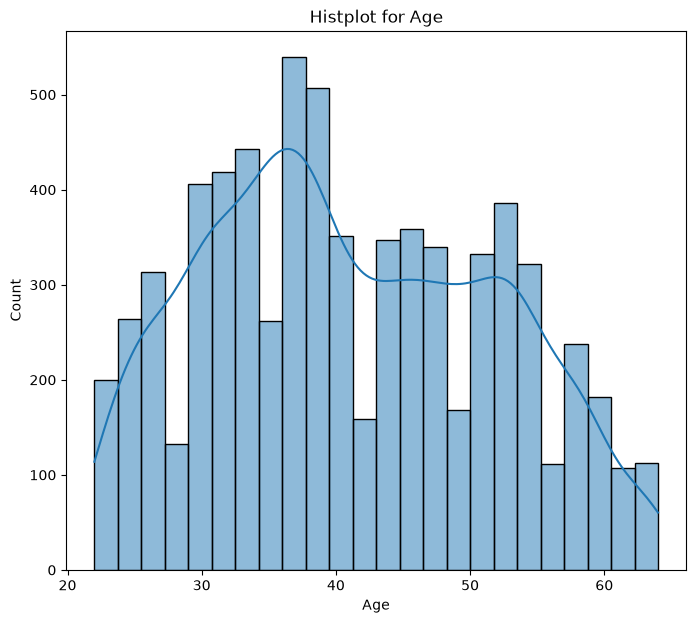

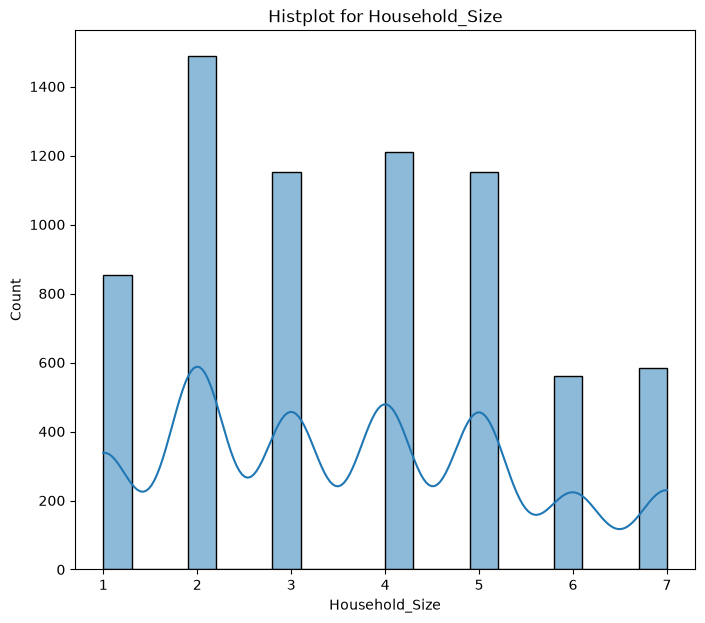

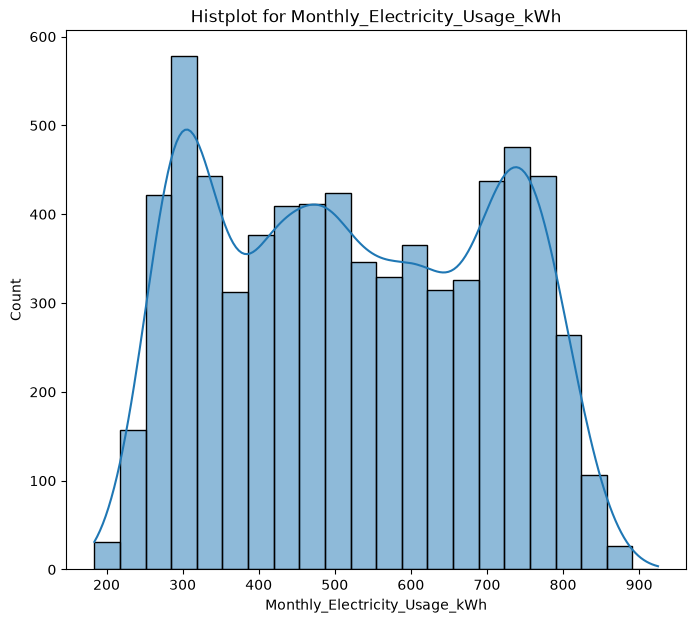

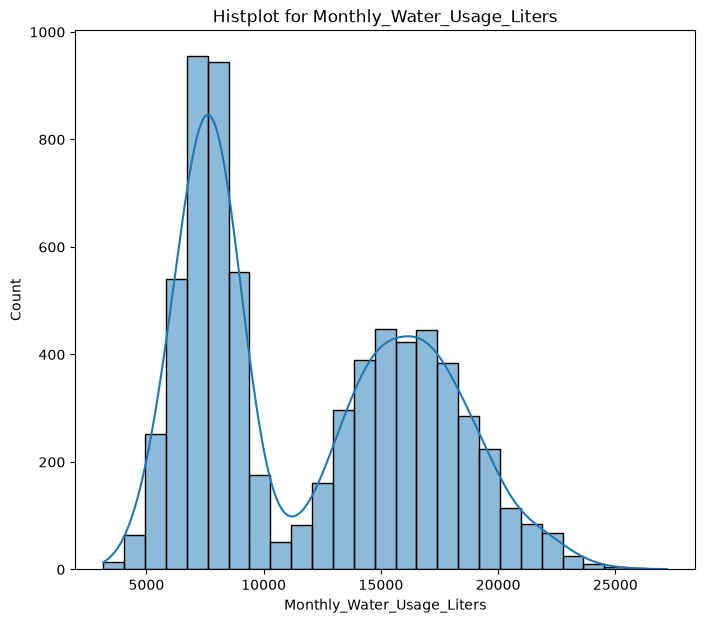

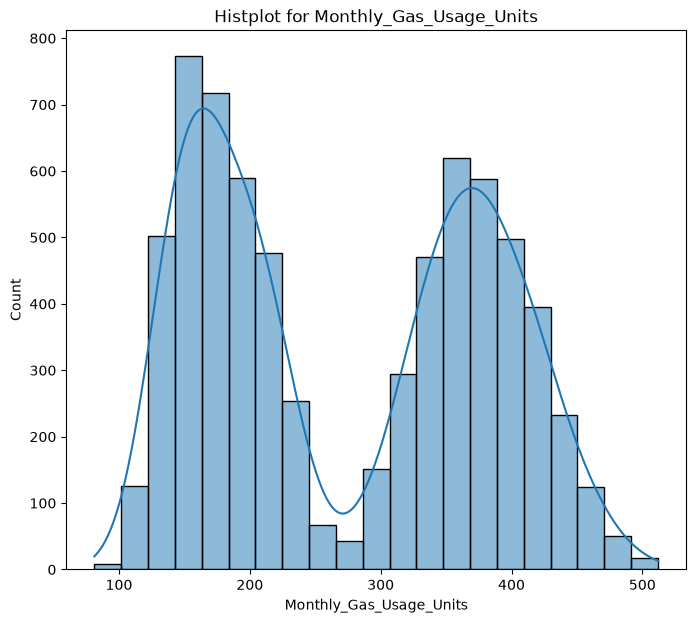

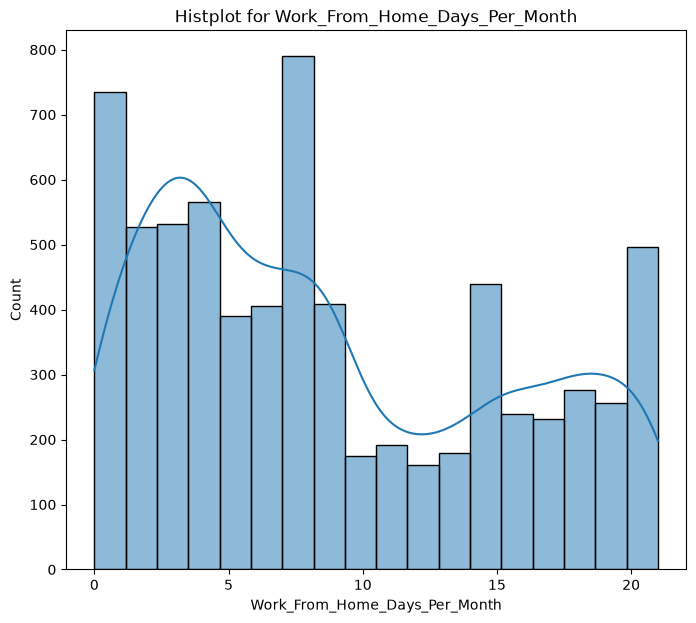

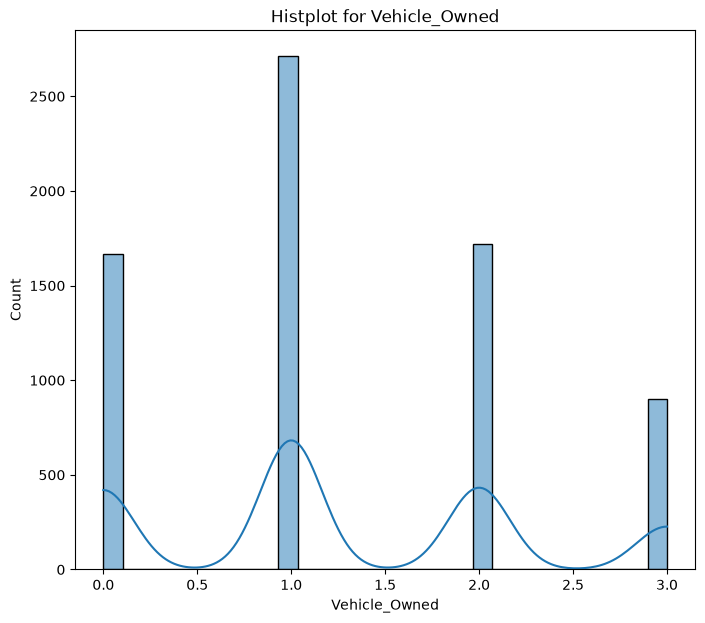

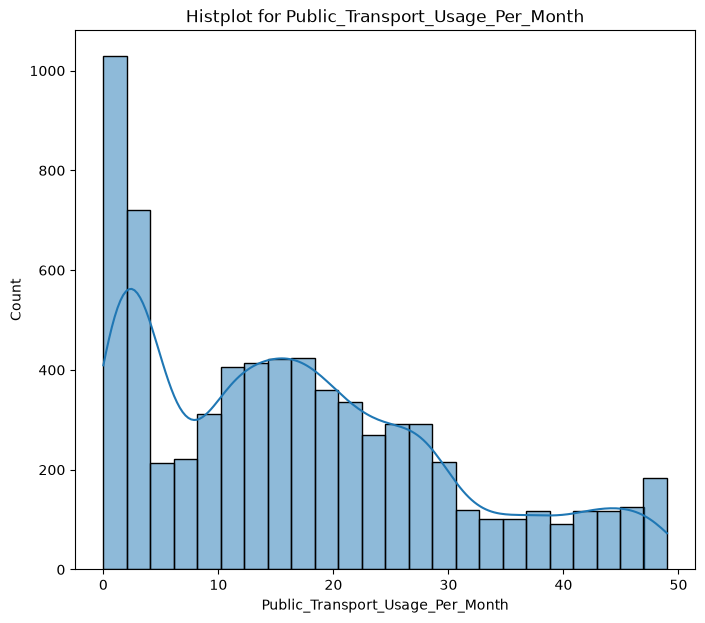

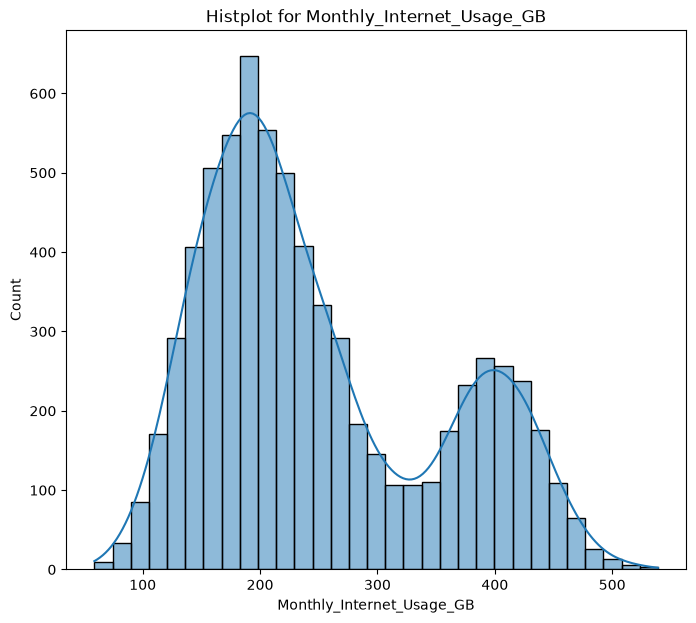

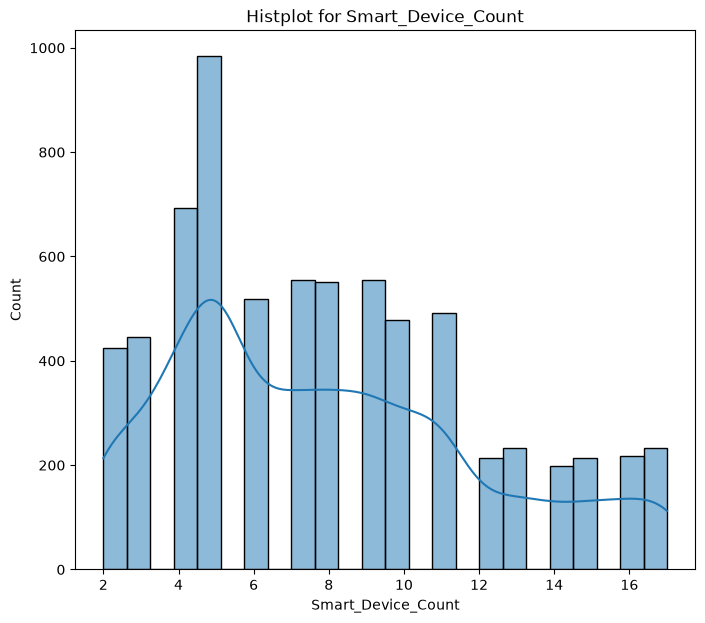

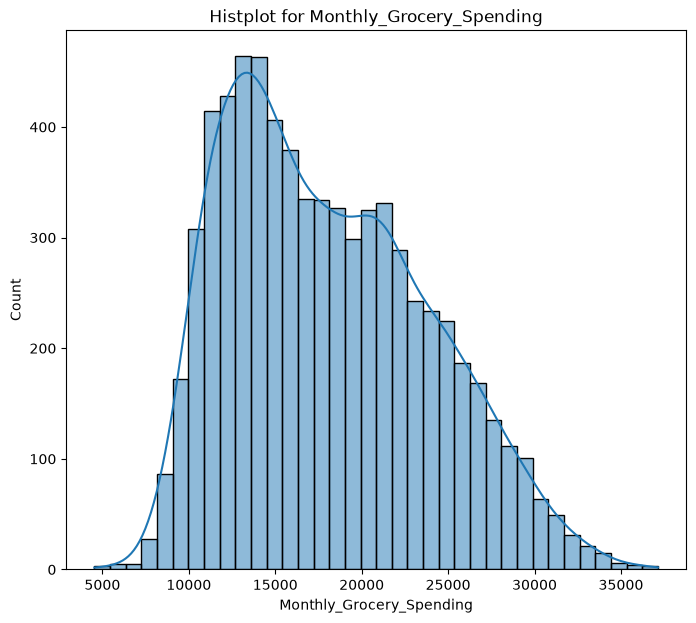

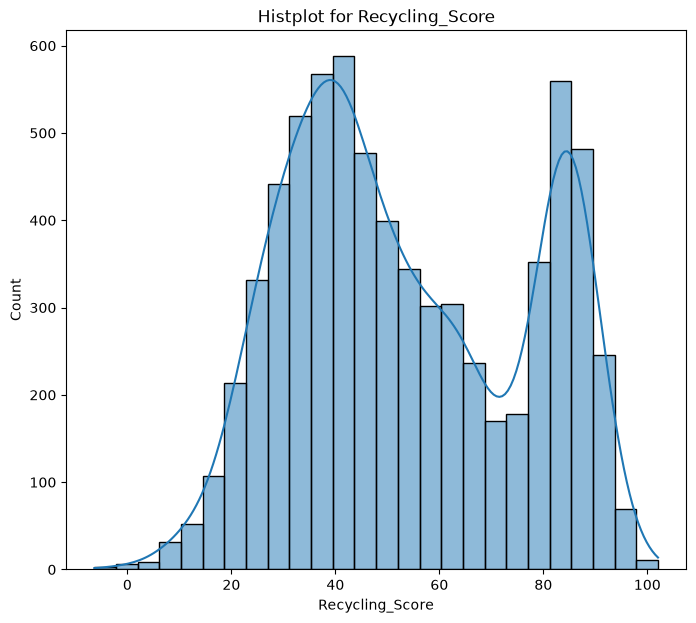

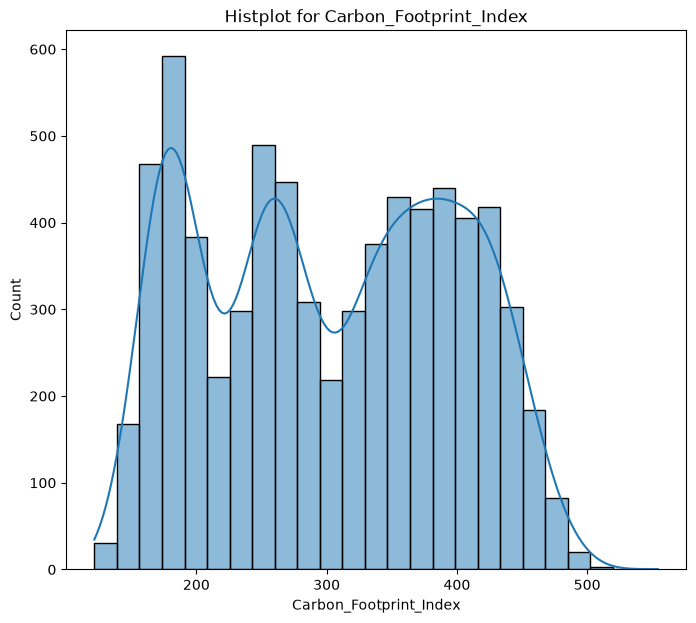

In [11]:
for col in df.select_dtypes(include='number'):
    plt.figure(figsize=(8,7))
    sns.histplot(df[col], kde=True)
    plt.title(f"Histplot for {col}")
    plt.show()

Using IQR for more info on outliers of monthly grocery shopping 

In [12]:
dfcopy = df.copy()

In [13]:
Q1 = dfcopy["Monthly_Grocery_Spending"].quantile(0.25)
Q3 = dfcopy["Monthly_Grocery_Spending"].quantile(0.75)

IQR = Q3 - Q1

lower_limit, upper_limit = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
print("Upper limit: ", upper_limit)
print("Lower limit: ", lower_limit)

iqr_counts = {}

iqr_counts["Monthly_Grocery_Spending"] = int(
    (
    (dfcopy["Monthly_Grocery_Spending"] < lower_limit) | (dfcopy["Monthly_Grocery_Spending"] > upper_limit)
    ).sum()
)

pd.DataFrame({ "IQR outliers": iqr_counts })

Upper limit:  35554.52812465353
Lower limit:  -76.95424711769556


,IQR outliers
Monthly_Grocery_Spending,7


There are outliers present but logically thinking there can be some household who spend a high amount for groceries so numerically they can be considered as outliers but logically they are valid values

## 3. Correlation analysis

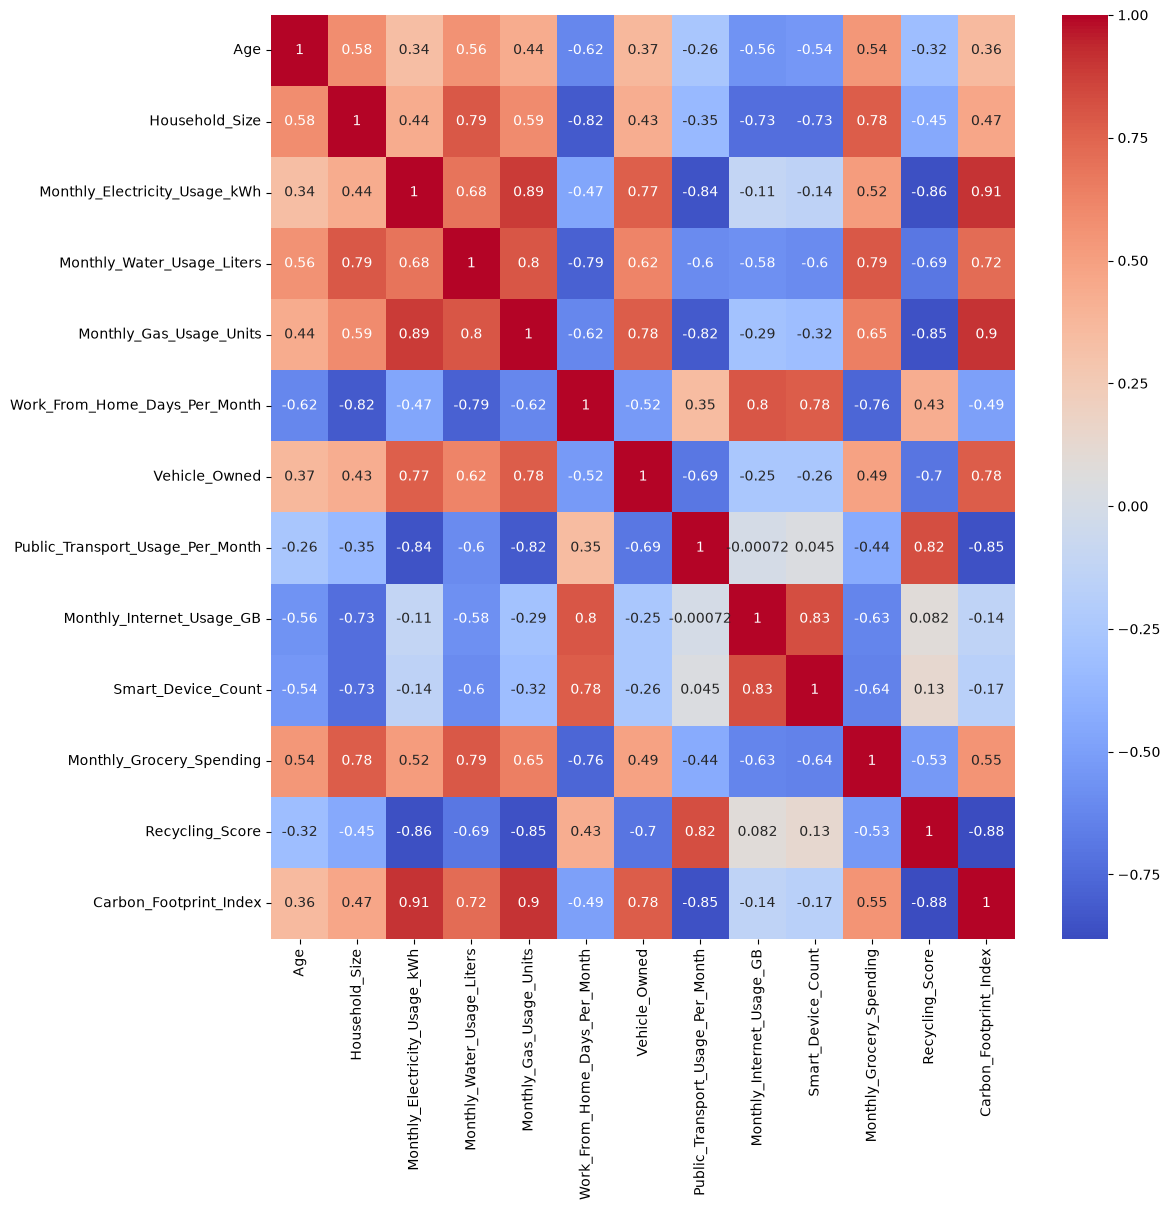

In [17]:
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(12,12))
sns.heatmap(
    corr, 
    annot=True,
    cmap="coolwarm"
)

plt.show()

#### Strong positive relations exist between:
- Carbon footprint and monthly electricity
- carbon footprint and monthly gas
- Recycling and public transport
- Smart device count and monthly internet usage
- monthly internet and work form home days
- monthly ags and monthly electric
- monthly gas and monthly water

#### Strong negative relations exist between:
- carbon footprint and recycling
- carbon footprint and public transport
- recycling and monthly electricity
- recycling and monthly gas
- public transport and monthly electricity
- public transport and monthly gas
- Work from home days and household size

## 4. Feature Scaling

In [19]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(dfcopy)

scaled_df = pd.DataFrame(scaled_data, columns=dfcopy.columns)

scaled_df.head()

,Age,Household_Size,Monthly_Electricity_Usage_kWh,Monthly_Water_Usage_Liters,Monthly_Gas_Usage_Units,Work_From_Home_Days_Per_Month,Vehicle_Owned,Public_Transport_Usage_Per_Month,Monthly_Internet_Usage_GB,Smart_Device_Count,Monthly_Grocery_Spending,Recycling_Score,Carbon_Footprint_Index
0,1.312740,1.888820,0.297925,0.880001,-0.232073,-1.383782,0.763248,-0.917600,-1.129820,-0.718799,0.758816,-0.629063,0.149670
1,0.279562,-0.904466,-1.485577,-0.604337,-0.898382,-0.597568,-0.274378,1.371441,-0.322806,0.020344,-0.470317,1.404180,-1.485821
2,-1.411093,0.212848,-1.150244,-0.772404,-1.803511,0.031404,-0.274378,0.684728,-0.705613,-0.718799,-0.831982,1.657849,-1.377824
3,0.467412,-0.345809,1.138599,0.127177,0.712996,-0.283082,0.763248,-1.299107,-0.010090,-0.226037,-0.027514,-1.270306,0.965115
4,-0.471840,-0.904466,-0.524082,-1.328752,-0.655145,1.446589,-0.274378,0.913632,1.244557,1.252250,-1.386797,-0.426361,-0.299784


In [20]:
scaled_df.describe()

,Age,Household_Size,Monthly_Electricity_Usage_kWh,Monthly_Water_Usage_Liters,Monthly_Gas_Usage_Units,Work_From_Home_Days_Per_Month,Vehicle_Owned,Public_Transport_Usage_Per_Month,Monthly_Internet_Usage_GB,Smart_Device_Count,Monthly_Grocery_Spending,Recycling_Score,Carbon_Footprint_Index
count,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03,7.000000e+03
mean,-8.628019e-17,-1.230762e-16,6.191872e-17,-2.821870e-16,2.689912e-16,6.927792e-17,-2.639159e-17,2.842171e-17,-8.425007e-17,6.191872e-17,2.471674e-16,1.806809e-16,-2.365092e-16
std,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00
min,-1.786794e+00,-1.463123e+00,-1.926685e+00,-1.790757e+00,-1.803511e+00,-1.383782e+00,-1.312004e+00,-1.299107e+00,-1.908057e+00,-1.457943e+00,-2.326852e+00,-2.659568e+00,-1.911837e+00
25%,-7.536160e-01,-9.044658e-01,-9.245708e-01,-8.980400e-01,-9.548734e-01,-9.120532e-01,-2.743779e-01,-9.366754e-01,-7.564479e-01,-7.187994e-01,-8.184331e-01,-8.036212e-01,-9.252214e-01
50%,-9.613920e-02,2.128483e-01,-5.484213e-02,-3.347598e-01,-1.637927e-01,-2.830820e-01,-2.743779e-01,-1.545865e-01,-2.911843e-01,-2.260371e-01,-1.393570e-01,-2.017225e-01,-1.333574e-02
75%,8.431133e-01,7.715054e-01,9.282848e-01,8.906982e-01,9.120383e-01,8.569284e-01,7.632480e-01,6.084270e-01,7.574581e-01,7.594875e-01,7.171620e-01,1.005984e+00,8.705520e-01
max,2.158067e+00,1.888820e+00,2.258076e+00,3.097542e+00,2.195461e+00,1.918317e+00,1.800874e+00,2.439660e+00,2.877085e+00,2.237774e+00,3.294209e+00,2.139206e+00,2.655978e+00


In [22]:
print("Mean of each column: \n ", scaled_df.mean())

print("\n Standard deviation of each column: \n ", scaled_df.std())

Mean of each column: 
  Age                                -8.628019e-17
Household_Size                     -1.230762e-16
Monthly_Electricity_Usage_kWh       6.191872e-17
Monthly_Water_Usage_Liters         -2.821870e-16
Monthly_Gas_Usage_Units             2.689912e-16
Work_From_Home_Days_Per_Month       6.927792e-17
Vehicle_Owned                      -2.639159e-17
Public_Transport_Usage_Per_Month    2.842171e-17
Monthly_Internet_Usage_GB          -8.425007e-17
Smart_Device_Count                  6.191872e-17
Monthly_Grocery_Spending            2.471674e-16
Recycling_Score                     1.806809e-16
Carbon_Footprint_Index             -2.365092e-16
dtype: float64

 Standard deviation of each column: 
  Age                                 1.000071
Household_Size                      1.000071
Monthly_Electricity_Usage_kWh       1.000071
Monthly_Water_Usage_Liters          1.000071
Monthly_Gas_Usage_Units             1.000071
Work_From_Home_Days_Per_Month       1.000071
Vehicle_Owned 

## 5. Using the elbow method to find values of K

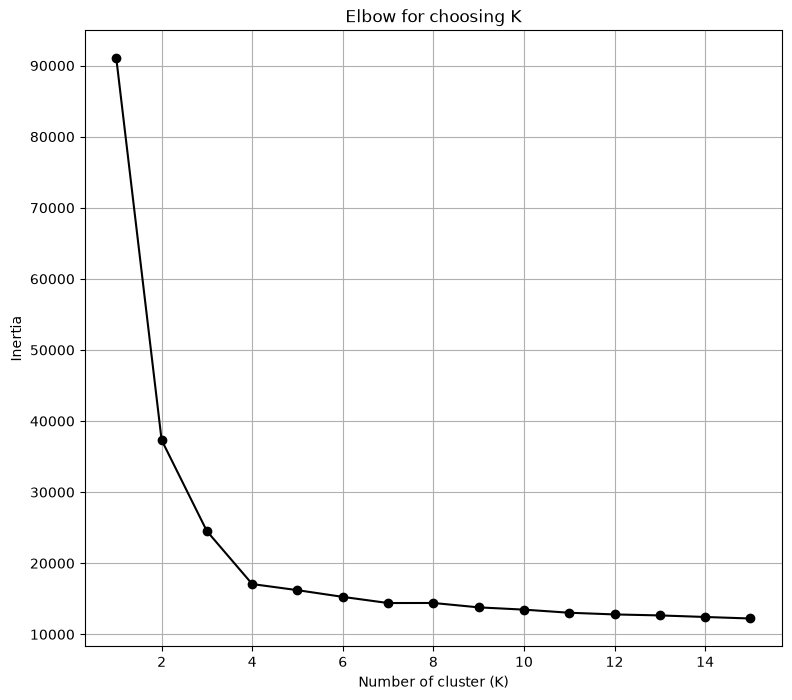

In [23]:
inertia_values = []

for k in range(1, 16): 
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(9,8))
plt.plot(range(1, 16), inertia_values, marker="o", color="black")
plt.xlabel("Number of cluster (K)")
plt.ylabel("Inertia")
plt.title("Elbow for choosing K")
plt.grid(True)
plt.show()

## 6. Using Silhouette method to find values of k

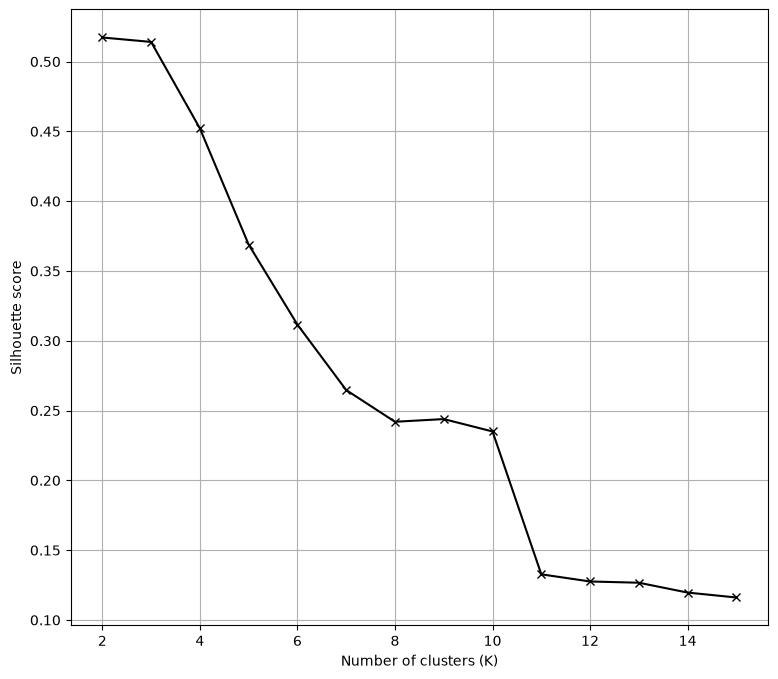

In [25]:
silhouette_scores = []

for k in range(2, 16):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    score = silhouette_score(scaled_df, kmeans.labels_)
    silhouette_scores.append(score)

plt.figure(figsize=(9,8))
plt.plot(range(2, 16), silhouette_scores, marker="x", color="black")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()

#### K = 4
Choosing the value of K = 4 based on the elbow and the silhouette score because there were two possible values of k 3 & 4 and out of which 4 seems appropriate for the dataset as the number of groups it gives are in accordance to the result we would like to obtain

## 7. Applying the K Means clustering for K = 4

In [26]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(scaled_df)

dfcopy["Cluster"] = kmeans.labels_

dfcopy.head()

,Age,Household_Size,Monthly_Electricity_Usage_kWh,Monthly_Water_Usage_Liters,Monthly_Gas_Usage_Units,Work_From_Home_Days_Per_Month,Vehicle_Owned,Public_Transport_Usage_Per_Month,Monthly_Internet_Usage_GB,Smart_Device_Count,Monthly_Grocery_Spending,Recycling_Score,Carbon_Footprint_Index,Cluster
0,55,7,577.815435,16297.185213,250.452177,0,2,5,136.910641,5,22434.354466,39.515578,316.954231,3
1,44,2,262.106859,8997.944363,178.673805,5,1,35,217.895776,8,15304.246020,85.444985,162.026964,2
2,26,4,321.466128,8171.473190,81.168415,9,1,26,179.480453,5,13206.258639,91.175188,172.257279,2
3,46,3,726.628283,12595.167596,352.260102,7,2,0,249.277214,7,17872.913293,25.030369,394.199926,1
4,36,2,432.306960,5435.629369,204.876572,18,1,29,375.182923,13,9987.818482,44.094452,274.378229,0


In [27]:
dfcopy["Cluster"].value_counts()

Cluster
3    1750
2    1750
1    1750
0    1750
Name: count, dtype: int64

## 8. PCA visualization

Before the clustering

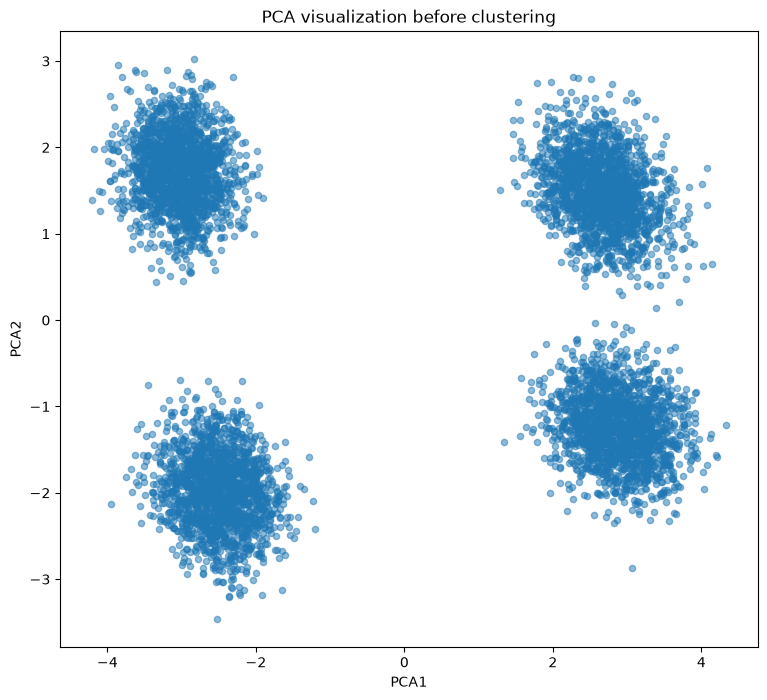

In [28]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_df)

plt.figure(figsize=(9,8))
plt.scatter(pca_components[:, 0], pca_components[:, 1], s=20, alpha=0.5)
plt.title("PCA visualization before clustering")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

After clustering

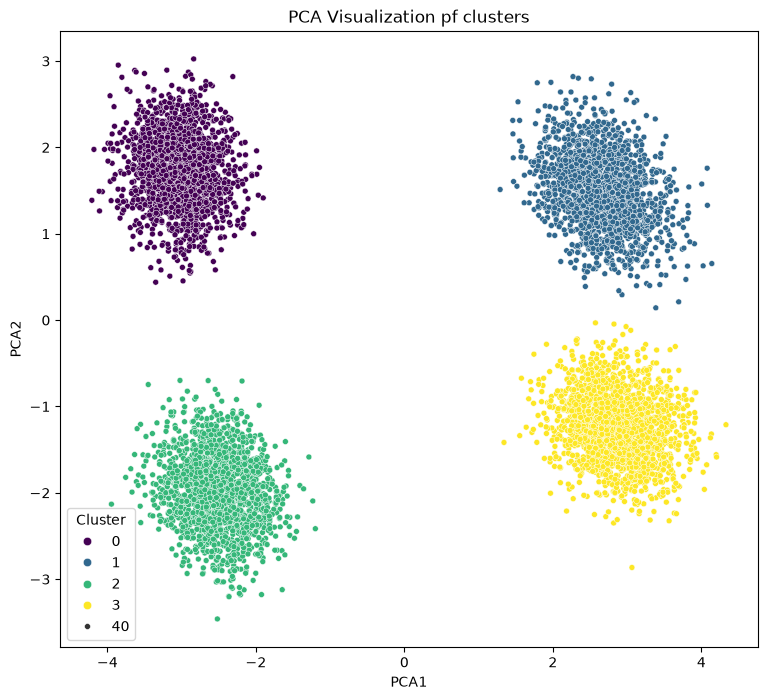

In [32]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_df)

pca_df = pd.DataFrame(data=pca_components, columns=["PCA1", "PCA2"])
pca_df["Cluster"] = dfcopy["Cluster"]

plt.figure(figsize=(9,8))
sns.scatterplot(x="PCA1", y="PCA2", hue="Cluster", palette="viridis", data=pca_df, size=40)
plt.title("PCA Visualization pf clusters")
plt.show()

## 9. Cluster interpretation

In [33]:
cluster_profile = dfcopy.groupby("Cluster").mean()

cluster_profile

,Age,Household_Size,Monthly_Electricity_Usage_kWh,Monthly_Water_Usage_Liters,Monthly_Gas_Usage_Units,Work_From_Home_Days_Per_Month,Vehicle_Owned,Public_Transport_Usage_Per_Month,Monthly_Internet_Usage_GB,Smart_Device_Count,Monthly_Grocery_Spending,Recycling_Score,Carbon_Footprint_Index
Cluster,,,,,,,,,,,,,
0,30.314286,1.511429,448.876713,7027.599480,200.480825,18.018857,0.532000,19.514286,400.990650,13.502286,11975.946000,59.732986,260.043784
1,44.696571,3.970286,751.237282,14991.260797,400.472015,5.634857,2.514857,2.013143,249.566034,8.073143,20104.796474,30.179974,420.692474
2,39.790857,3.006857,300.953823,7988.514442,150.323926,9.571429,0.514286,34.406857,200.379827,6.578857,14990.054436,85.009882,179.809737
3,49.292571,5.987429,599.243945,17871.721339,350.532572,1.976000,1.496571,12.169714,150.222700,3.515429,25059.283808,39.979684,350.558924


- Cluster 0 = Youngest & Heavy digital household (highest work form home, device and internet usage)
- Cluster 1 = Heavy home usage household (Highest carbon footprint having highest electricity and gas usage)
- Cluster 2 = Eco-friendly household (Highest public transport and recycling score with lowest electricity and gas and  average water usage)
- Cluster 3 = Large families (Oldest with highest household size highest water usage and higher than average electricity and gas usage lowest digital usage highest grocery and high than average carbon footprint)

## 10. Visualization

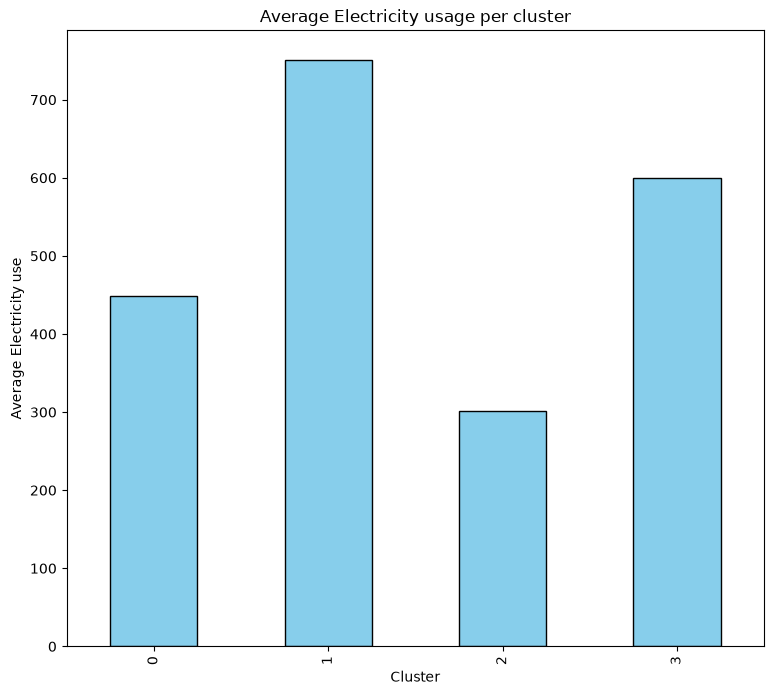

In [34]:
plt.figure(figsize=(9,8))
cluster_profile["Monthly_Electricity_Usage_kWh"].plot(kind="bar", color='skyblue', edgecolor="#010101")
plt.title("Average Electricity usage per cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Electricity use")
plt.show()

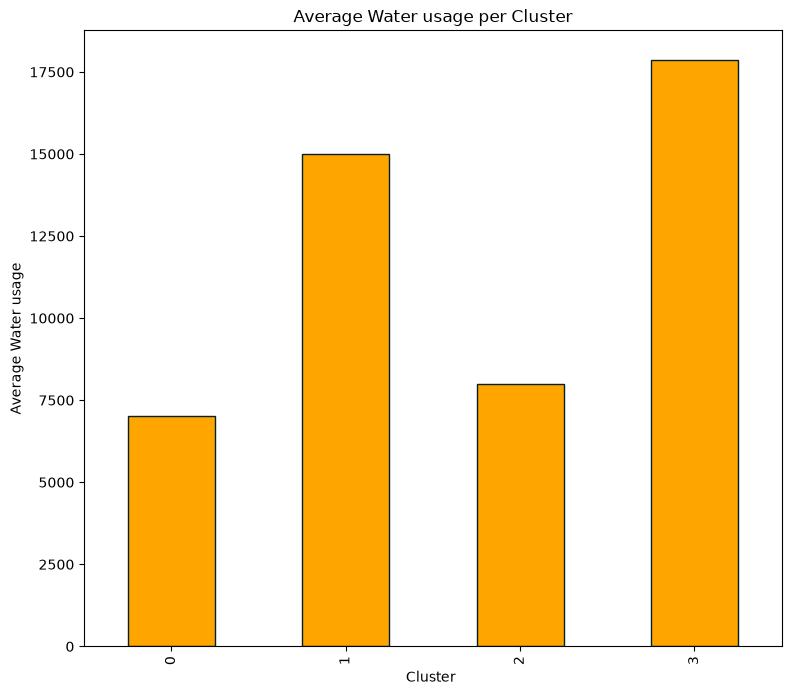

In [35]:
plt.figure(figsize=(9,8))
cluster_profile["Monthly_Water_Usage_Liters"].plot(kind="bar", color="orange", edgecolor="#022020")
plt.title("Average Water usage per Cluster")
plt.xlabel("Cluster ")
plt.ylabel("Average Water usage")
plt.show()

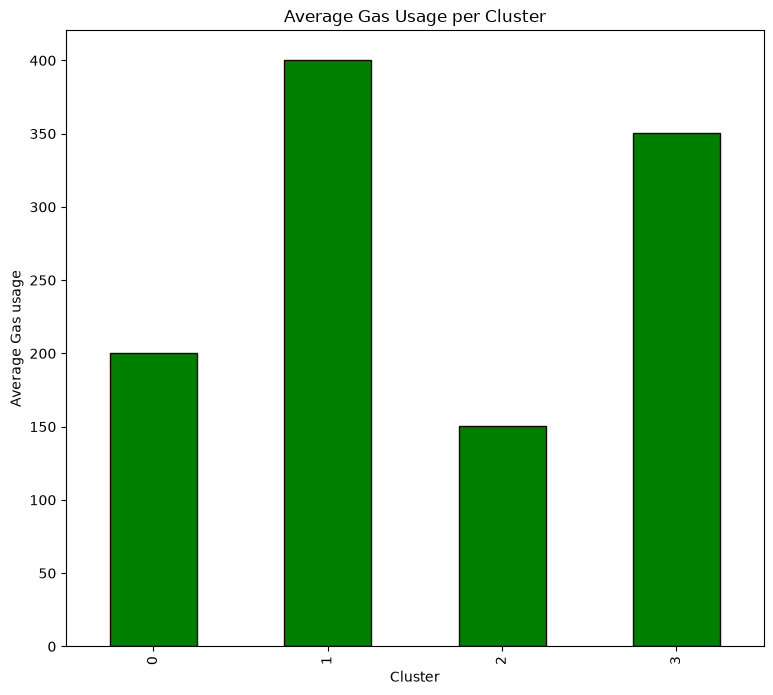

In [36]:
plt.figure(figsize=(9,8))
cluster_profile["Monthly_Gas_Usage_Units"].plot(kind="bar", color="green", edgecolor="#200202")
plt.title("Average Gas Usage per Cluster")
plt.xlabel('Cluster')
plt.ylabel("Average Gas usage")
plt.show()

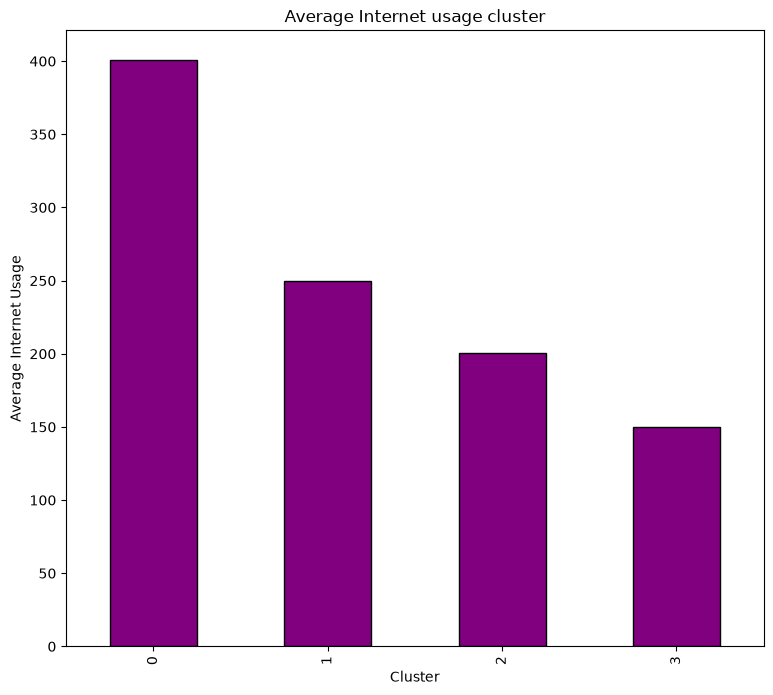

In [ ]:
plt.figure(figsize=(9,8))
cluster_profile["Monthly_Internet_Usage_GB"].plot(kind="bar", color="purple", edgecolor="#010101")
plt.title("Average Internet usage cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Internet Usage")
plt.show()

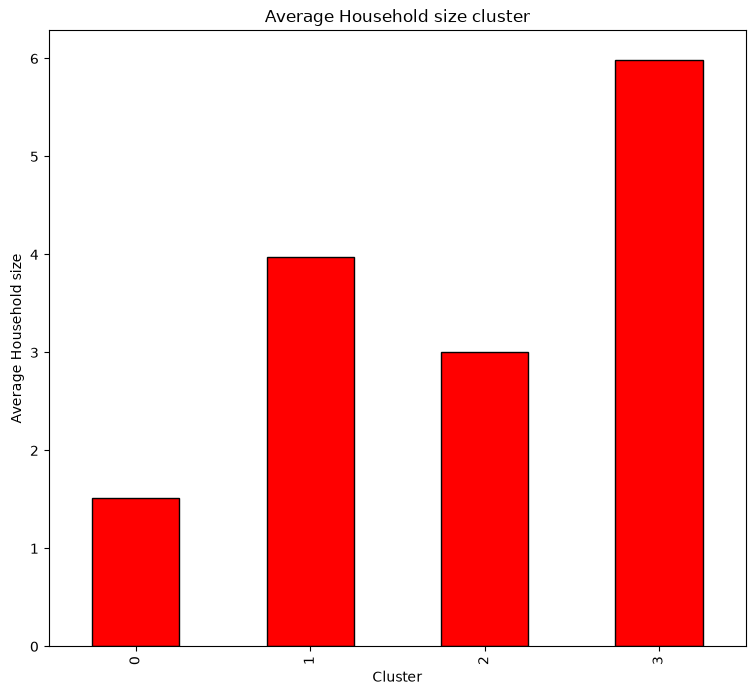

In [ ]:
plt.figure(figsize=(9,8))
cluster_profile["Household_Size"].plot(kind="bar", color="red", edgecolor="#030303")
plt.title("Average Household size cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Household")
plt.show()

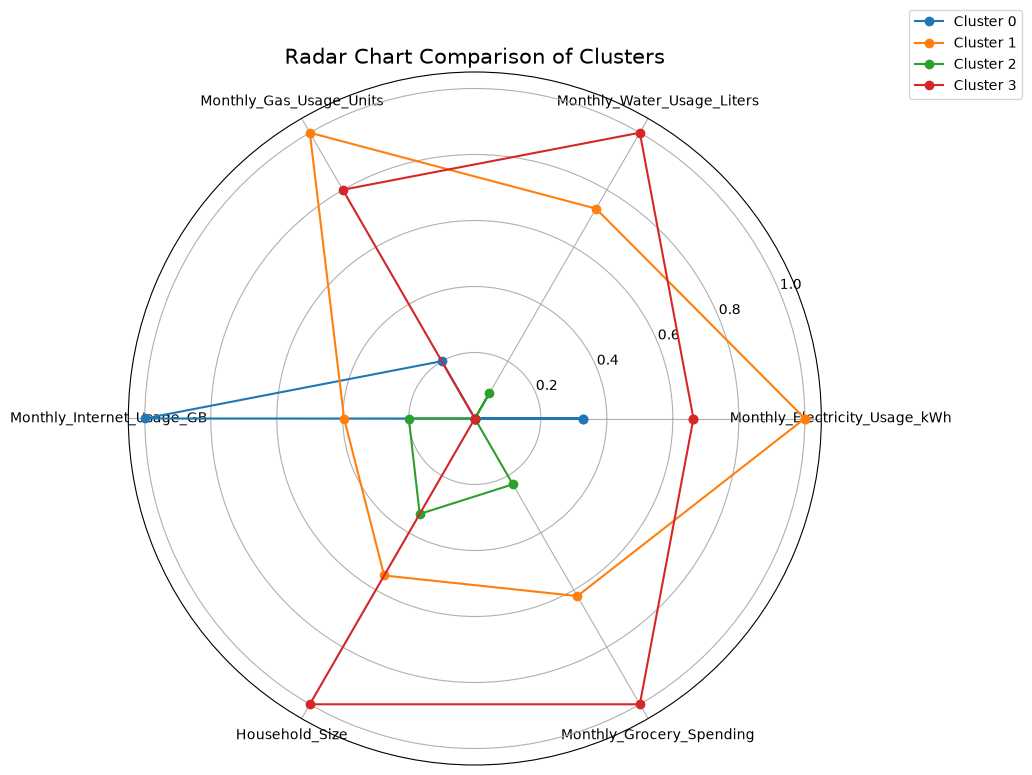

In [39]:
features = ['Monthly_Electricity_Usage_kWh', 'Monthly_Water_Usage_Liters', 'Monthly_Gas_Usage_Units', 'Monthly_Internet_Usage_GB', 'Household_Size', 'Monthly_Grocery_Spending']
    
data = cluster_profile[features]

data_norm = (data - data.min()) / (data.max() - data.min())

num_vars = len(features)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(9, 9))

for i in range(len(data_norm)):
    values = data_norm.iloc[i].tolist()
    values += values[:1]

    plt.polar(angles, values, marker='o', label=f'Cluster {i}')

plt.xticks(angles[:-1], features)
plt.title("Radar Chart Comparison of Clusters", size=15)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()